# Step 1 of RAG: Document Loading and Chunking Strategies

**RAG** (Retrieval-Augmented Generation) has 4 core steps:

1. **Document Loading & Chunking** ← *this notebook*
2. Generating Embeddings
3. Storing in a Vector Database
4. Retrieval + passing context to an LLM

Before we can embed or search anything, we need **text**, split into small, meaningful pieces
called **chunks**. This notebook covers *why* chunking matters and *how* to do it several ways.

### What you will learn
1. Why we can't just feed a whole document to an embedding model
2. Loading a `.txt` document
3. Loading a `.pdf` document
4. Chunking Strategy 1 — Fixed-size character chunking (from scratch)
5. Chunking Strategy 2 — `CharacterTextSplitter` (LangChain)
6. Chunking Strategy 3 — `RecursiveCharacterTextSplitter` (LangChain, recommended default)
7. Chunking Strategy 4 — Sentence-based chunking
8. Chunking Strategy 5 — Token-based chunking (important for LLM token limits)
9. Comparing all strategies side by side

## Why Chunking Matters

- Embedding models have a **maximum input length** (e.g. ~256-512 tokens for many free models).
- A whole book or long article won't fit, and even if it did, one giant embedding would blur together
  too many different ideas — making search results useless.
- **Chunking** splits a document into smaller pieces so each chunk represents one focused idea,
  which produces much more accurate embeddings and search results later on.

### Setup — Install Required Libraries

In [1]:
!pip install -q langchain langchain-text-splitters tiktoken pypdf fpdf2

## 1. Create a Sample Document (so this notebook runs with zero external downloads)

In real projects your document would come from a file, website, or database. Here we generate one
locally so the notebook is 100% reliable and network-independent.

In [2]:
import os

os.makedirs("docs", exist_ok=True)

article_text = """Artificial Intelligence: An Overview

Artificial Intelligence, or AI, is the field of computer science focused on building systems
that can perform tasks which normally require human intelligence. These tasks include
understanding language, recognizing images, making decisions, and learning from experience.

Machine Learning is a subset of AI where systems learn patterns from data instead of following
hardcoded rules. Instead of programming every decision by hand, we feed the system many examples,
and it learns the underlying pattern on its own. This approach powers everything from spam filters
to recommendation systems.

Deep Learning takes Machine Learning further by using neural networks with many layers. These
layered networks can automatically discover complex patterns in large amounts of data, such as
recognizing faces in photos or understanding the meaning of a sentence.

Natural Language Processing, or NLP, is the branch of AI that focuses specifically on human
language. NLP powers chatbots, translation tools, and search engines. A key building block of
modern NLP is the embedding, which converts words or sentences into numeric vectors that capture
meaning.

Retrieval-Augmented Generation, or RAG, is a technique that combines a search system with a
language model. Instead of relying only on what a language model memorized during training, RAG
first retrieves relevant, up-to-date information from a document collection, then passes that
information to the model so it can generate a more accurate, grounded answer.

Vector Databases store embeddings and allow fast similarity search across millions of documents.
They are a core infrastructure piece behind modern RAG systems, chatbots, and recommendation
engines used by companies around the world today.
"""

with open("docs/sample_article.txt", "w") as f:
    f.write(article_text)

print("Document created: docs/sample_article.txt")
print("Total characters:", len(article_text))
print("Total words:", len(article_text.split()))

Document created: docs/sample_article.txt
Total characters: 1786
Total words: 262


## 2. Loading a `.txt` Document

The simplest form of document loading — read the raw text from disk.

In [3]:
with open("docs/sample_article.txt", "r") as f:
    loaded_text = f.read()

print("Loaded document preview:\n")
print(loaded_text[:300], "...")

Loaded document preview:

Artificial Intelligence: An Overview

Artificial Intelligence, or AI, is the field of computer science focused on building systems
that can perform tasks which normally require human intelligence. These tasks include
understanding language, recognizing images, making decisions, and learning from exp ...


## 3. Loading a `.pdf` Document

Most real-world knowledge bases include PDFs. We'll first generate a simple sample PDF (so this
notebook needs no external file), then load and extract its text using `pypdf`.

In [4]:
from fpdf import FPDF

pdf = FPDF()
pdf.add_page()
pdf.set_font("Times", size=12)

for line in article_text.split("\n"):
    # Using an explicit width (e.g., 190mm for A4 page with margins) instead of 0
    pdf.multi_cell(190, 8, line)

pdf.output("docs/sample_article.pdf")
print("PDF created: docs/sample_article.pdf")

PDF created: docs/sample_article.pdf


In [5]:
from pypdf import PdfReader

reader = PdfReader("docs/sample_article.pdf")

pdf_text = ""
for page in reader.pages:
    pdf_text += page.extract_text() + "\n"

print("Pages found:", len(reader.pages))
print("\nExtracted PDF text preview:\n")
print(pdf_text[:300], "...")

Pages found: 1

Extracted PDF text preview:

Artificial Intelligence: An Overview
Artificial Intelligence, or AI, is the field of computer science focused on building systems
that can perform tasks which normally require human intelligence. These tasks include
understanding language, recognizing images, making decisions, and learning from expe ...


**Discussion Point:** Loading is format-specific (`.txt`, `.pdf`, `.docx`, HTML, etc.) but the goal isalways the same — end up with **plain text** that we can chunk. From here on we'll work with the textwe loaded from the `.txt` file.

## 4. Chunking Strategy 1 — Fixed-Size Character Chunking (From Scratch)
The simplest strategy: cut the text every N characters, with some overlap between chunks so wedon't lose context at the boundaries.

In [6]:
def fixed_size_chunking(text, chunk_size=300, overlap=50):
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])
        start += chunk_size - overlap
    return chunks

fixed_chunks = fixed_size_chunking(loaded_text, chunk_size=300, overlap=50)

print("Number of chunks:", len(fixed_chunks))
print("\n--- Chunk 1 ---\n", fixed_chunks[0])
print("\n--- Chunk 2 ---\n", fixed_chunks[1])

Number of chunks: 8

--- Chunk 1 ---
 Artificial Intelligence: An Overview

Artificial Intelligence, or AI, is the field of computer science focused on building systems
that can perform tasks which normally require human intelligence. These tasks include
understanding language, recognizing images, making decisions, and learning from exp

--- Chunk 2 ---
 ng images, making decisions, and learning from experience.

Machine Learning is a subset of AI where systems learn patterns from data instead of following
hardcoded rules. Instead of programming every decision by hand, we feed the system many examples,
and it learns the underlying pattern on its own


**Discussion Point:** Notice fixed-size chunking can cut a sentence or word right in half — it doesn'tknow anything about paragraph or sentence boundaries. It's simple and fast, but not always ideal.

## 5. Chunking Strategy 2 — `CharacterTextSplitter` (LangChain)
LangChain provides ready-made splitters. `CharacterTextSplitter` is the library version of what wejust built by hand — it splits on a chosen separator (like a blank line) and respects `chunk_size`.

In [7]:
from langchain_text_splitters import CharacterTextSplitter

char_splitter = CharacterTextSplitter(
    separator="\n\n",
    chunk_size=300,
    chunk_overlap=50
)

char_chunks = char_splitter.split_text(loaded_text)

print("Number of chunks:", len(char_chunks))
for i, chunk in enumerate(char_chunks):
    print(f"\n--- Chunk {i+1} ({len(chunk)} chars) ---")
    print(chunk)

Created a chunk of size 318, which is longer than the specified 300
Created a chunk of size 359, which is longer than the specified 300


Number of chunks: 7

--- Chunk 1 (36 chars) ---
Artificial Intelligence: An Overview

--- Chunk 2 (270 chars) ---
Artificial Intelligence, or AI, is the field of computer science focused on building systems
that can perform tasks which normally require human intelligence. These tasks include
understanding language, recognizing images, making decisions, and learning from experience.

--- Chunk 3 (318 chars) ---
Machine Learning is a subset of AI where systems learn patterns from data instead of following
hardcoded rules. Instead of programming every decision by hand, we feed the system many examples,
and it learns the underlying pattern on its own. This approach powers everything from spam filters
to recommendation systems.

--- Chunk 4 (260 chars) ---
Deep Learning takes Machine Learning further by using neural networks with many layers. These
layered networks can automatically discover complex patterns in large amounts of data, such as
recognizing faces in photos or understanding the 

## 6. Chunking Strategy 3 — `RecursiveCharacterTextSplitter` (Recommended Default)
This is the most commonly used splitter in real RAG systems. It tries to split on paragraph breaksfirst, then sentences, then words — only falling back to a hard character cut as a last resort. Thiskeeps chunks much more semantically coherent.

In [8]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50,
    separators=["\n\n", "\n", ". ", " ", ""]
)

recursive_chunks = recursive_splitter.split_text(loaded_text)

print("Number of chunks:", len(recursive_chunks))
for i, chunk in enumerate(recursive_chunks):
    print(f"\n--- Chunk {i+1} ({len(chunk)} chars) ---")
    print(chunk)

Number of chunks: 9

--- Chunk 1 (36 chars) ---
Artificial Intelligence: An Overview

--- Chunk 2 (270 chars) ---
Artificial Intelligence, or AI, is the field of computer science focused on building systems
that can perform tasks which normally require human intelligence. These tasks include
understanding language, recognizing images, making decisions, and learning from experience.

--- Chunk 3 (291 chars) ---
Machine Learning is a subset of AI where systems learn patterns from data instead of following
hardcoded rules. Instead of programming every decision by hand, we feed the system many examples,
and it learns the underlying pattern on its own. This approach powers everything from spam filters

--- Chunk 4 (26 chars) ---
to recommendation systems.

--- Chunk 5 (260 chars) ---
Deep Learning takes Machine Learning further by using neural networks with many layers. These
layered networks can automatically discover complex patterns in large amounts of data, such as
recognizing faces in 

**Discussion Point:** Compare this output to Strategy 1. The recursive splitter tends to end chunks atnatural breaks (end of a paragraph or sentence) instead of mid-word — this is why it's the most widelyused default in production RAG pipelines.

## 7. Chunking Strategy 4 — Sentence-Based Chunking
Sometimes we want every chunk to contain whole sentences only — useful when precision matters morethan fixed size (e.g. legal or medical documents).

In [9]:
import re

def sentence_chunking(text, sentences_per_chunk=2):
    # Simple sentence splitter using punctuation (no extra downloads needed)
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    sentences = [s for s in sentences if s]

    chunks = []
    for i in range(0, len(sentences), sentences_per_chunk):
        chunk = " ".join(sentences[i:i + sentences_per_chunk])
        chunks.append(chunk)
    return chunks

sentence_chunks = sentence_chunking(loaded_text, sentences_per_chunk=2)

print("Number of chunks:", len(sentence_chunks))
for i, chunk in enumerate(sentence_chunks[:4]):
    print(f"\n--- Chunk {i+1} ---")
    print(chunk)

Number of chunks: 7

--- Chunk 1 ---
Artificial Intelligence: An Overview

Artificial Intelligence, or AI, is the field of computer science focused on building systems
that can perform tasks which normally require human intelligence. These tasks include
understanding language, recognizing images, making decisions, and learning from experience.

--- Chunk 2 ---
Machine Learning is a subset of AI where systems learn patterns from data instead of following
hardcoded rules. Instead of programming every decision by hand, we feed the system many examples,
and it learns the underlying pattern on its own.

--- Chunk 3 ---
This approach powers everything from spam filters
to recommendation systems. Deep Learning takes Machine Learning further by using neural networks with many layers.

--- Chunk 4 ---
These
layered networks can automatically discover complex patterns in large amounts of data, such as
recognizing faces in photos or understanding the meaning of a sentence. Natural Language Proces

## 8. Chunking Strategy 5 — Token-Based
 models and LLMs actually have limits measured in **tokens**, not characters (roughly1 token ≈ 4 characters in English). Token-based chunking guarantees we never exceed a model's realinput limit.

In [10]:
import tiktoken

encoding = tiktoken.get_encoding("cl100k_base")

def token_chunking(text, max_tokens=60, overlap_tokens=10):
    tokens = encoding.encode(text)
    chunks = []
    start = 0
    while start < len(tokens):
        end = start + max_tokens
        chunk_tokens = tokens[start:end]
        chunks.append(encoding.decode(chunk_tokens))
        start += max_tokens - overlap_tokens
    return chunks

token_chunks = token_chunking(loaded_text, max_tokens=60, overlap_tokens=10)

print("Number of chunks:", len(token_chunks))
for i, chunk in enumerate(token_chunks[:3]):
    token_count = len(encoding.encode(chunk))
    print(f"\n--- Chunk {i+1} ({token_count} tokens) ---")
    print(chunk)

Number of chunks: 7

--- Chunk 1 (60 tokens) ---
Artificial Intelligence: An Overview

Artificial Intelligence, or AI, is the field of computer science focused on building systems
that can perform tasks which normally require human intelligence. These tasks include
understanding language, recognizing images, making decisions, and learning from experience.

Machine Learning is a subset of

--- Chunk 2 (60 tokens) ---
 learning from experience.

Machine Learning is a subset of AI where systems learn patterns from data instead of following
hardcoded rules. Instead of programming every decision by hand, we feed the system many examples,
and it learns the underlying pattern on its own. This approach powers everything from spam filters
to recommendation

--- Chunk 3 (60 tokens) ---
 This approach powers everything from spam filters
to recommendation systems.

Deep Learning takes Machine Learning further by using neural networks with many layers. These
layered networks can automatically disco

## 9. Comparing All Strategies Side by Side

In [11]:
import pandas as pd

comparison = pd.DataFrame({
    "Strategy": [
        "Fixed-size (scratch)",
        "CharacterTextSplitter",
        "RecursiveCharacterTextSplitter",
        "Sentence-based",
        "Token-based"
    ],
    "Number of Chunks": [
        len(fixed_chunks),
        len(char_chunks),
        len(recursive_chunks),
        len(sentence_chunks),
        len(token_chunks)
    ],
    "Avg Chunk Length (chars)": [
        round(sum(len(c) for c in fixed_chunks) / len(fixed_chunks), 1),
        round(sum(len(c) for c in char_chunks) / len(char_chunks), 1),
        round(sum(len(c) for c in recursive_chunks) / len(recursive_chunks), 1),
        round(sum(len(c) for c in sentence_chunks) / len(sentence_chunks), 1),
        round(sum(len(c) for c in token_chunks) / len(token_chunks), 1)
    ]
})

comparison

,Strategy,Number of Chunks,Avg Chunk Length (chars)
0,Fixed-size (scratch),8,265.2
1,CharacterTextSplitter,7,253.3
2,RecursiveCharacterTextSplitter,9,196.8
3,Sentence-based,7,253.4
4,Token-based,7,305.0


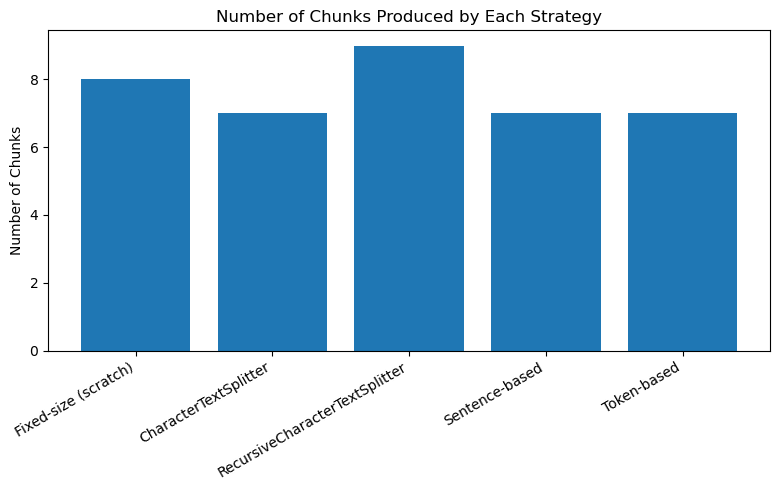

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(comparison["Strategy"], comparison["Number of Chunks"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Number of Chunks")
plt.title("Number of Chunks Produced by Each Strategy")
plt.tight_layout()
plt.show()

## Key Takeaways (Recap for Students)

| Strategy | Best For | Watch Out For |
|---|---|---|
| Fixed-size (scratch) | Learning the core idea | Can cut sentences/words in half |
| `CharacterTextSplitter` | Simple, separator-based splitting | Still fairly rigid |
| `RecursiveCharacterTextSplitter` | Most general-purpose RAG use cases | Slightly more setup, but worth it |
| Sentence-based | Precision-sensitive domains (legal, medical) | Chunk sizes vary a lot |
| Token-based | Respecting an embedding/LLM's exact token limit | Requires a tokenizer library |

**`chunk_overlap`** (used in most strategies above) keeps a bit of the previous chunk's text at the
start of the next chunk, so an idea that spans a chunk boundary isn't completely lost.

This notebook produced chunks — the **next step in RAG** is turning each chunk into an embedding
and storing it in a vector database (see the earlier notebooks in this series).

### Practice Exercises
1. Change `chunk_size` from 300 to 150 and re-run `RecursiveCharacterTextSplitter` — how does the
   number of chunks change?
2. Try `sentences_per_chunk=1` and `sentences_per_chunk=4` in the sentence-based strategy and compare.
3. Load your own `.txt` or `.pdf` file (upload it to Colab's file panel) and run all 5 strategies on it.

CHUNKING COMPARISON
   Chunk Size  Number of Chunks
0         300                 5
1         150                13

Number of chunks with size 300: 5
Number of chunks with size 150: 13


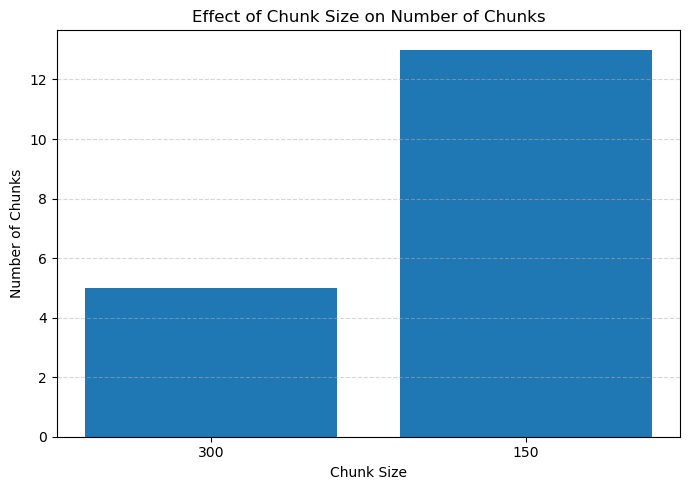

In [13]:
# ==========================================
# PRACTICE 1
# Compare chunk_size 300 and 150
# ==========================================

from langchain_text_splitters import RecursiveCharacterTextSplitter
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------
# 1. Sample text
# ------------------------------------------

text = """
Artificial Intelligence is a branch of computer science that focuses on
creating machines that can perform tasks that normally require human
intelligence. These tasks include learning, reasoning, problem solving,
understanding language, and recognizing images.

Machine learning is an important part of artificial intelligence. It allows
computers to learn patterns from data without being explicitly programmed
for every task. Machine learning algorithms can be used for classification,
prediction, recommendation, and many other applications.

Deep learning is another area of artificial intelligence. It uses neural
networks with multiple layers to process large amounts of data. Deep learning
has been successfully applied to image recognition, speech recognition,
natural language processing, and autonomous systems.

Retrieval Augmented Generation, commonly called RAG, combines information
retrieval with generative artificial intelligence. In a RAG system, documents
are divided into smaller pieces called chunks. These chunks can then be
converted into embeddings and stored in a vector database.

When a user asks a question, the system searches the vector database for
relevant chunks. The retrieved information is then provided to a language
model to generate a useful response. Good chunking is therefore an important
step in building an effective RAG system.
"""


# ------------------------------------------
# 2. Chunk size = 300
# ------------------------------------------

splitter300 = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50
)

chunks300 = splitter300.split_text(text)


# ------------------------------------------
# 3. Chunk size = 150
# ------------------------------------------

splitter150 = RecursiveCharacterTextSplitter(
    chunk_size=150,
    chunk_overlap=50
)

chunks150 = splitter150.split_text(text)


# ------------------------------------------
# 4. Create comparison table
# ------------------------------------------

comparison1 = pd.DataFrame({
    "Chunk Size": [300, 150],
    "Number of Chunks": [
        len(chunks300),
        len(chunks150)
    ]
})

print("CHUNKING COMPARISON")
print("===================")
print(comparison1)


# ------------------------------------------
# 5. Display the chunks
# ------------------------------------------

print("\nNumber of chunks with size 300:",
      len(chunks300))

print("Number of chunks with size 150:",
      len(chunks150))


# ------------------------------------------
# 6. Create graph
# ------------------------------------------

plt.figure(figsize=(7, 5))

plt.bar(
    comparison1["Chunk Size"].astype(str),
    comparison1["Number of Chunks"]
)

plt.xlabel("Chunk Size")
plt.ylabel("Number of Chunks")
plt.title("Effect of Chunk Size on Number of Chunks")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()
plt.show()

SENTENCE-BASED CHUNKING COMPARISON
   Sentences per Chunk  Number of Chunks
0                    1                17
1                    4                 5

--- Example: 1 Sentence per Chunk ---

Chunk 1:
Artificial Intelligence is a branch of computer science.

Chunk 2:
It focuses on creating machines that can perform tasks that normally require human intelligence.

Chunk 3:
These tasks include learning, reasoning, problem solving, and understanding language.

--- Example: 4 Sentences per Chunk ---

Chunk 1:
Artificial Intelligence is a branch of computer science. It focuses on creating machines that can perform tasks that normally require human intelligence. These tasks include learning, reasoning, problem solving, and understanding language. Machine learning is an important part of artificial intelligence.

Chunk 2:
It allows computers to learn patterns from data without being explicitly programmed for every task. Machine learning can be used for classification, prediction, recomm

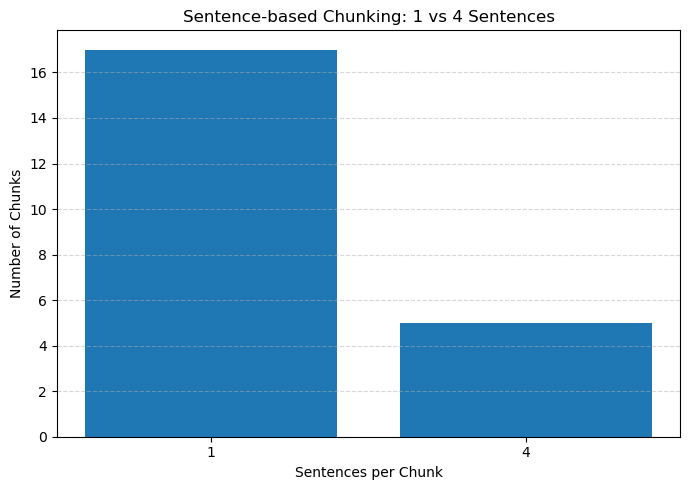

In [14]:
# ==========================================
# PRACTICE 2
# Compare 1 sentence vs 4 sentences per chunk
# ==========================================

import re
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------
# 1. Sample text
# ------------------------------------------

text = """
Artificial Intelligence is a branch of computer science.
It focuses on creating machines that can perform tasks that normally require human intelligence.
These tasks include learning, reasoning, problem solving, and understanding language.
Machine learning is an important part of artificial intelligence.
It allows computers to learn patterns from data without being explicitly programmed for every task.
Machine learning can be used for classification, prediction, recommendation, and many other applications.
Deep learning is another area of artificial intelligence.
It uses neural networks with multiple layers to process large amounts of data.
Deep learning is widely used in image recognition and speech recognition.
Natural language processing allows computers to understand and process human language.
Retrieval Augmented Generation is commonly called RAG.
RAG combines information retrieval with generative artificial intelligence.
In a RAG system, documents are divided into smaller pieces called chunks.
These chunks can then be converted into embeddings and stored in a vector database.
When a user asks a question, the system searches the vector database for relevant chunks.
The retrieved information is then provided to a language model to generate a useful response.
Good chunking is therefore an important step in building an effective RAG system.
"""


# ------------------------------------------
# 2. Split text into sentences
# ------------------------------------------

sentences = re.split(r'(?<=[.!?])\s+', text.strip())


# ------------------------------------------
# 3. Function for sentence-based chunking
# ------------------------------------------

def sentence_chunker(sentence_list, sentences_per_chunk):

    chunks = []

    for i in range(0, len(sentence_list), sentences_per_chunk):

        chunk = " ".join(
            sentence_list[i:i + sentences_per_chunk]
        )

        chunks.append(chunk)

    return chunks


# ------------------------------------------
# 4. Create chunks
# ------------------------------------------

chunks1 = sentence_chunker(sentences, 1)

chunks4 = sentence_chunker(sentences, 4)


# ------------------------------------------
# 5. Comparison table
# ------------------------------------------

comparison2 = pd.DataFrame({

    "Sentences per Chunk": [
        1,
        4
    ],

    "Number of Chunks": [
        len(chunks1),
        len(chunks4)
    ]
})


print("SENTENCE-BASED CHUNKING COMPARISON")
print("===================================")

print(comparison2)


# ------------------------------------------
# 6. Display some chunks
# ------------------------------------------

print("\n--- Example: 1 Sentence per Chunk ---")

for i, chunk in enumerate(chunks1[:3], 1):
    print(f"\nChunk {i}:")
    print(chunk)


print("\n--- Example: 4 Sentences per Chunk ---")

for i, chunk in enumerate(chunks4[:2], 1):
    print(f"\nChunk {i}:")
    print(chunk)


# ------------------------------------------
# 7. Create graph
# ------------------------------------------

plt.figure(figsize=(7, 5))

plt.bar(
    comparison2["Sentences per Chunk"].astype(str),
    comparison2["Number of Chunks"]
)

plt.xlabel("Sentences per Chunk")

plt.ylabel("Number of Chunks")

plt.title(
    "Sentence-based Chunking: 1 vs 4 Sentences"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.show()

CHUNKING STRATEGY COMPARISON
      Strategy  Number of Chunks  Average Chunk Length
    Fixed-size                 2                 290.0
     Character                 3                 192.0
     Recursive                 3                 192.0
Sentence-based                 5                 114.8
   Token-based                 2                 288.5


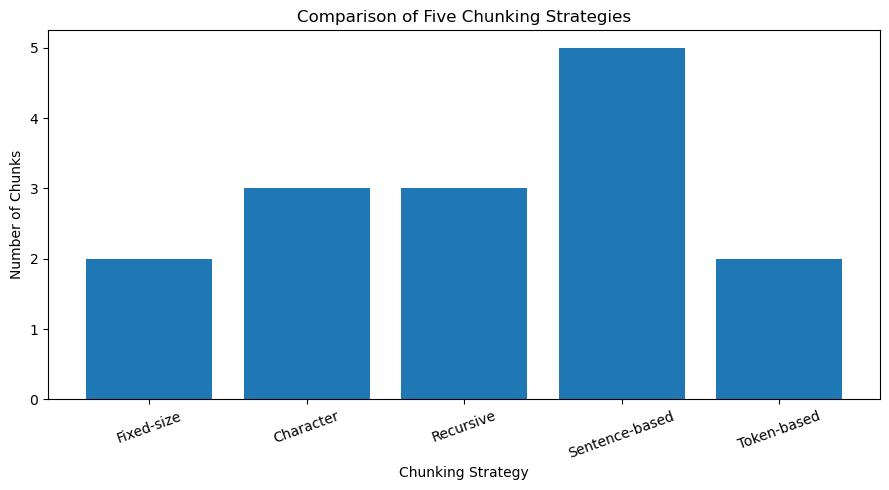

In [15]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from langchain_text_splitters import CharacterTextSplitter, RecursiveCharacterTextSplitter

# Sample document
text = """
Artificial Intelligence is a branch of computer science.
Machine learning allows computers to learn from data.
Deep learning uses neural networks for complex tasks.
Natural language processing helps computers understand human language.
Retrieval Augmented Generation is used in many modern AI systems.
RAG systems divide documents into smaller chunks.
These chunks are stored and retrieved when needed.
Different chunking methods produce different results.
Choosing a suitable chunking method is important for RAG.
Good chunking can improve the quality of retrieved information.
"""

# 1. Fixed-size chunking
fixed_chunks = [
    text[i:i+300]
    for i in range(0, len(text), 300)
]

# 2. Character-based chunking
char_splitter = CharacterTextSplitter(
    separator="\n",
    chunk_size=300,
    chunk_overlap=30
)

char_chunks = char_splitter.split_text(text)

# 3. Recursive chunking
recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=30
)

recursive_chunks = recursive_splitter.split_text(text)

# 4. Sentence-based chunking
sentences = re.split(r'(?<=[.!?])\s+', text.strip())

sentence_chunks = [
    " ".join(sentences[i:i+2])
    for i in range(0, len(sentences), 2)
]

# 5. Token-based approximation
words = text.split()

token_chunks = [
    " ".join(words[i:i+50])
    for i in range(0, len(words), 50)
]

# Put all chunks together
all_chunks = [
    fixed_chunks,
    char_chunks,
    recursive_chunks,
    sentence_chunks,
    token_chunks
]

# Comparison table
comparison = pd.DataFrame({
    "Strategy": [
        "Fixed-size",
        "Character",
        "Recursive",
        "Sentence-based",
        "Token-based"
    ],
    "Number of Chunks": [
        len(x) for x in all_chunks
    ],
    "Average Chunk Length": [
        round(sum(len(c) for c in x) / len(x), 1)
        for x in all_chunks
    ]
})

print("CHUNKING STRATEGY COMPARISON")
print("=" * 40)
print(comparison.to_string(index=False))

# Graph
plt.figure(figsize=(9, 5))

plt.bar(
    comparison["Strategy"],
    comparison["Number of Chunks"]
)

plt.xlabel("Chunking Strategy")
plt.ylabel("Number of Chunks")
plt.title("Comparison of Five Chunking Strategies")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()